In [2]:
%cd ~/Code/naam

import numpy as np
import matplotlib.pyplot as plt
from naam import models
import torch



%load_ext autoreload
%autoreload 2

np.random.seed(42)
    
# Step 1: Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use the first CUDA device
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")  # Fallback to CPU if GPU is not available
    print("GPU is not available, using CPU instead.")



# etas = torch.concatenate((binary_spec_1,binary_spec_2),1)

# print("Storing and retriving memories...")
# x, S, P, initial_distance, final_distance,x0 = models.integrate_dynamics(N=etas.shape[0], K = etas.shape[1], NUM_STEPS=int(1e3), dt=0.1, beta=5, corruption_level=0.3, 
#                         etas=etas, memory_to_seed_from=1, device=device)


/u/leokoz8/Code/naam
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using GPU: Tesla V100-SXM2-32GB


/u/leokoz8/Code/naam
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using GPU: Tesla V100-SXM2-32GB
Loaded 10 MNIST digits (one of each class).
etas shape: torch.Size([784, 10])
Storing and retrieving memories...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 884.82it/s]


Initial L2 distance of neural state to memory 1 is 16.124515533447266
Final L2 distance of neural state to memory 1 is 6.0
Dynamics complete.
Initial distance: 16.124515533447266
Final distance:   6.0


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 784/784 [00:11<00:00, 69.21it/s]
/tmp/ipykernel_266128/2816610343.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


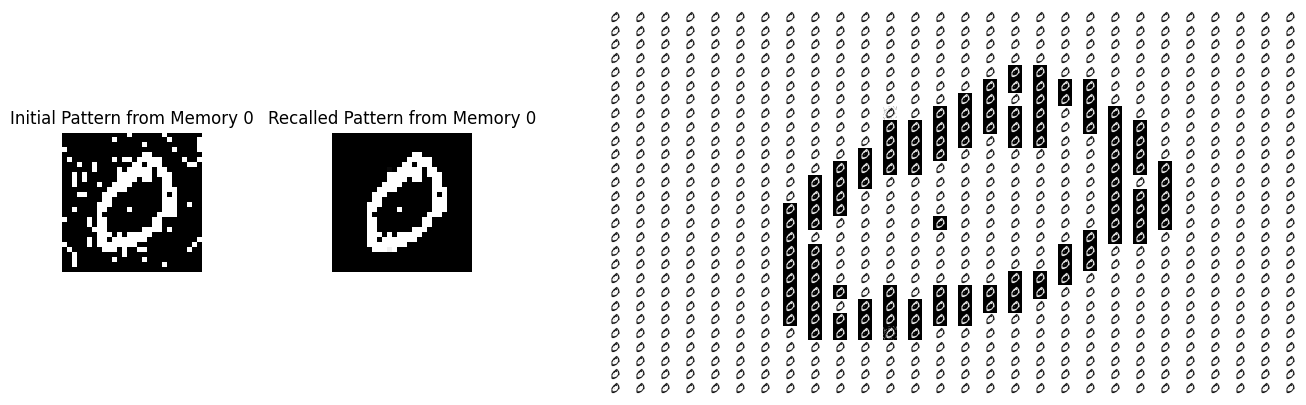

In [18]:
%cd ~/Code/naam

import numpy as np
import matplotlib.pyplot as plt
from naam import models
import torch
from torchvision import datasets, transforms
from matplotlib import gridspec
from tqdm import tqdm


%load_ext autoreload
%autoreload 2

# Fix random seed for reproducibility
np.random.seed(40)

# Step 1: Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU instead.")

##############################################################################
# 1. Load MNIST
##############################################################################
transform = transforms.Compose([
    transforms.ToTensor()  # image in [0,1]
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

##############################################################################
# 2. Pick exactly one sample of each digit 0..9
##############################################################################
digits_collected = []
labels_collected = []

for img, label in mnist_train:
    if label not in labels_collected:
        digits_collected.append(img)      # shape (1, 28, 28)
        labels_collected.append(label)
    if len(labels_collected) == 10:
        break

# Now we have exactly 10 images, each corresponding to a distinct digit [0..9]
# digits_collected is a list of 10 tensors, each (1, 28, 28)

##############################################################################
# 3. Binarize each digit into {-1, +1}
##############################################################################
# Stack them into shape (10, 1, 28, 28)
images = torch.stack(digits_collected, dim=0)  # shape = (10, 1, 28, 28)

# Flatten to (10, 784)
images = images.view(10, 28 * 28)

# Simple threshold-based binarization:
#   Pixel >= 0.5 => +1
#   Pixel <  0.5 => -1
binarized_images = torch.where(images >= 0.5, 
                               torch.tensor(1.0), 
                               torch.tensor(-1.0))

# Now shape is (10, 784). We want (784, 10) for etas.
etas = binarized_images.T  # shape = (784, 10)

# Move to device
etas = etas.to(device)

# K=10
print(f"Loaded 10 MNIST digits (one of each class).")
print(f"etas shape: {etas.shape}")  # (784, 10)

##############################################################################
# 4. Run integrate_dynamics
##############################################################################
print("Storing and retrieving memories...")

x, S, P, initial_distance, final_distance, x0 = models.integrate_dynamics(
    N=etas.shape[0],   # 784
    K=etas.shape[1],   # 10
    NUM_STEPS=int(4e3),
    dt=0.1,
    beta=2,
    corruption_level=0.1,
    etas=etas,
    memory_to_seed_from=1,  # which memory index to use for initial seed
    device=device
)

print("Dynamics complete.")
print(f"Initial distance: {initial_distance}")
print(f"Final distance:   {final_distance}")

##############################################################################
# 5. Visualize the recalled pattern
##############################################################################
# 'x' is a single 784-dim vector if you're retrieving from one memory

# Reshape x0 to show the initial pattern
initial_pattern = x0.detach().cpu().numpy().reshape(28, 28)
# Reshape x to show the recalled pattern
recalled_pattern = x.detach().cpu().numpy().reshape(28, 28)

# Create one figure, 1 row × 3 columns
fig = plt.figure(figsize=(16, 5))
outer_gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 5], wspace=0.4)

##############################################################################
# 1) First subplot: initial pattern
##############################################################################
ax0 = fig.add_subplot(outer_gs[0, 0])
ax0.imshow(initial_pattern, cmap='gray')
ax0.set_title("Initial Pattern from Memory 0")
ax0.axis('off')

##############################################################################
# 2) Second subplot: recalled pattern
##############################################################################
ax1 = fig.add_subplot(outer_gs[0, 1])
ax1.imshow(recalled_pattern, cmap='gray')
ax1.set_title("Recalled Pattern from Memory 0")
ax1.axis('off')


##############################################################################
# 3) Third subplot: 28×28 grid of patterns from S
#    We'll nest 28×28 sub-subplots in this one.
##############################################################################
# Create a nested GridSpec inside the third column
gs_mosaic = gridspec.GridSpecFromSubplotSpec(
    28, 28,  # 28 rows, 28 columns of small subplots
    subplot_spec=outer_gs[0, 2],
    wspace=0.0, hspace=0.0  # no space between sub-subplots
)

# Loop over the 28*28 patterns
for i in tqdm(range(28 * 28)):
    row = i // 28
    col = i % 28

    ax = fig.add_subplot(gs_mosaic[row, col])
    # Each S[i, :] is shape (784,)
    img = torch.tanh(2*S[i, :]).detach().cpu().numpy().reshape(28, 28)

    ax.imshow(img, cmap='gray')
    ax.axis('off')

# Finally, show everything
plt.tight_layout()


plt.savefig('mnist_synaptic_pattern.pdf',dpi = 300)

plt.show()